[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/blob/main/notebook.ipynb)

## Libraries

In [1]:
import torch
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore')
import numpy as np
import os
import random
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"       # to force BERT determinsm

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # per multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

## Download Github files

In [2]:
try:
    import google.colab
    %mkdir data
    %mkdir scripts
    %mkdir results
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/data/INA_dataset.json -O data/INA_dataset.json
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/models.py -O scripts/models.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/utils.py -O scripts/utils.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/embedding.py -O scripts/embedding.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/cv_folding.py -O scripts/cv_folding.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/configure.py -O scripts/configure.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/plotting.py -O scripts/plotting.py
    print("Working on Colab!")
except:
    print("Not Working on Colab ... or cannot dwnload Githb files!")
    pass

Not Working on Colab ... or cannot dwnload Githb files!


## Load dataset

In [3]:
import sys, os

DATA_PATH = "data" # "your-path-to-data"
dataset = "MIMIC"
if dataset == "INA":
    datafile =  "INA_dataset.json"
    target_var = "is_alive?"
    evfields = ['code_descr']
    static_vars = ["gender", "age_group", "primary_disease"]
    disease_list = ["SCD", "CHA", "NHOC", "AS", "AHD", "NTDT", "IM", "TDT", "OD"]
    remove_events = ['followup', 'platelet_change', 'bmi_change', 'thrombosys']
    thresh = 0.3
elif dataset == "MIMIC":
    datafile = "MIMIC_dataset.json"
    static_vars = ["gender", "age_at_splenectomy", "primary_disease"]
    disease_list = ["OD", "CHA", "SP", "THA", "AHD", "SCD"]
    target_var = "is_alive?"
    evfields = ['event']
    remove_events = ['drug']
    thresh = 0.3
else:
    raise Exception("dataset not supported!")

class settings:
  def __init__(self, datafile):
    self.dataset = pd.read_json(datafile)
    self.pathology_field = 'primary_disease'
    self.static_vars= static_vars
    self.target_var = target_var
    self.evfields = evfields
    self.remove_events = remove_events
    self.enable_plot=True
    self.n_splits=5
    self.num_epochs=10
    self.batch_size = 16
    self.embedding_dim=128
    self.hidden_dim=300
    self.random_state=42
    self.iter=5
    self.results_dir="results"

args = settings(os.path.join(DATA_PATH, datafile))
args.dataset.head(20)

,id,gender,age_group,is_splenectomized?,age_at_splenectomy,primary_disease,is_alive?,cause_of_death,events
0,10004235,M,mature,NO,None,OD - Oncological Diseases,YES,None,"[{'type': 'infection', 'event': 'Septicemia du..."
1,10004401,M,geriatric,NO,None,CHA - Congenital Hemolytic Anemias,NO,Chronic or unspecified duodenal ulcer with hem...,"[{'type': 'disease', 'event': 'Acute posthemor..."
2,10008460,F,elder,NO,None,OD - Oncological Diseases,YES,None,"[{'type': 'disease', 'event': 'Endometrial int..."
3,10008924,F,mature,NO,None,OD - Oncological Diseases,YES,None,"[{'type': 'disease', 'event': 'Spontaneous bac..."
4,10015701,F,geriatric,NO,None,OD - Oncological Diseases,YES,None,"[{'type': 'disease', 'event': 'Other malignant..."
5,10015988,M,geriatric,YES,None,OD - Oncological Diseases,YES,None,"[{'type': 'infection', 'event': 'Pneumonia due..."
6,10018862,F,elder,NO,None,OD - Oncological Diseases,YES,None,"[{'type': 'disease', 'event': 'Epigastric pain..."
7,10019003,F,elder,NO,None,OD - Oncological Diseases,YES,None,"[{'type': 'disease', 'event': 'Other and unspe..."
8,10023486,M,elder,NO,None,OD - Oncological Diseases,YES,None,"[{'type': 'disease', 'event': 'Major laceratio..."
9,10024451,M,elder,NO,None,OD - Oncological Diseases,YES,None,"[{'type': 'disease', 'event': 'Cholangitis', '..."


### Plot dataset distributions

<Figure size 640x480 with 0 Axes>

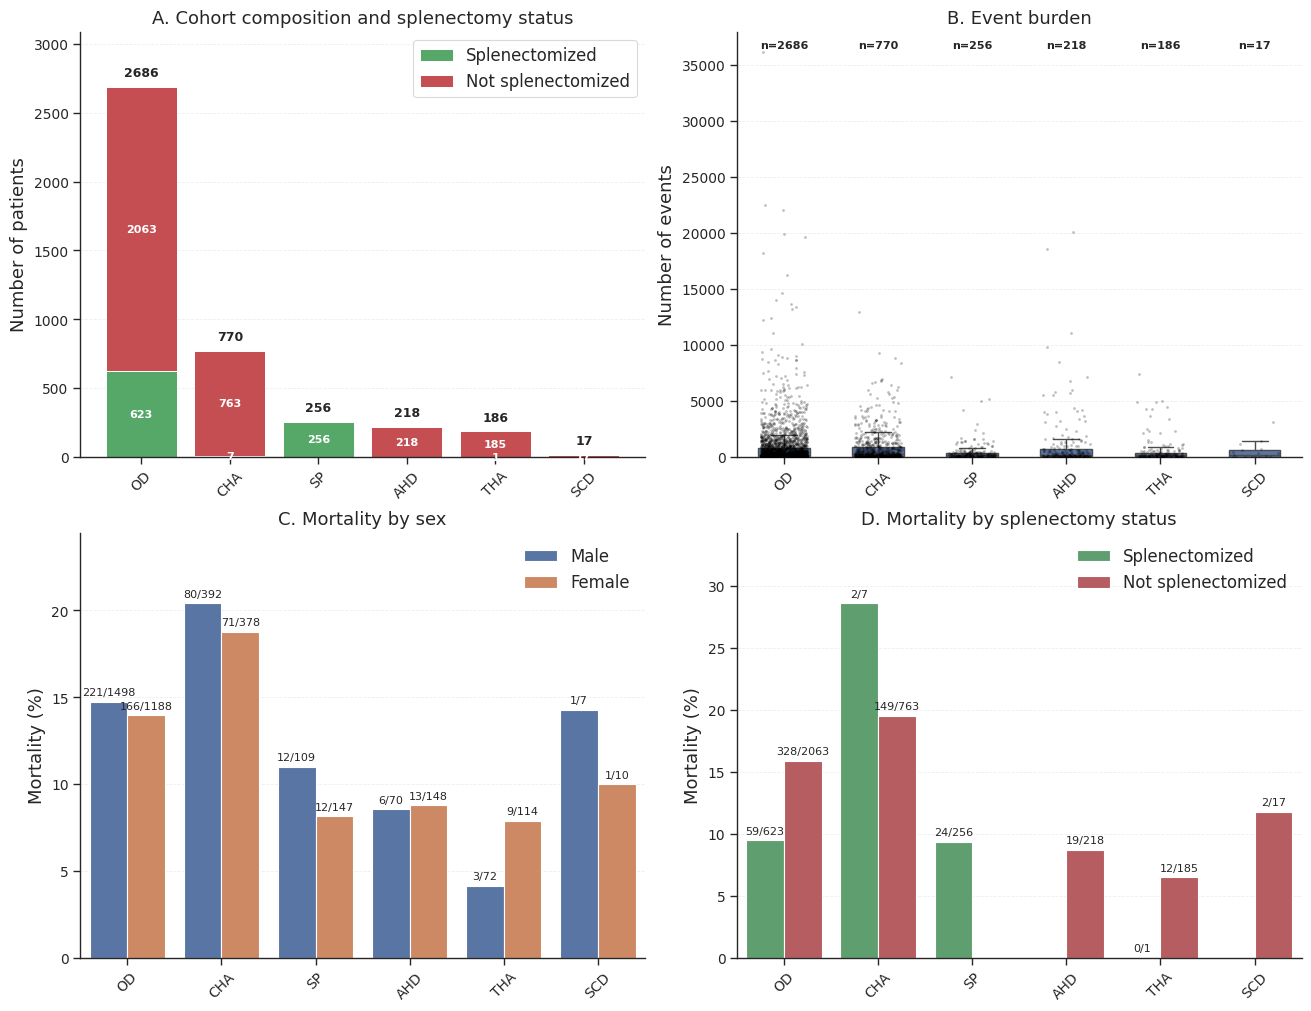

In [4]:
from scripts.plotting import plot_distrib
fig = plot_distrib(args.dataset, dict(zip(list(args.dataset["primary_disease"].unique()), disease_list)))

### Select splenectomize patients

In [5]:
args.dataset = args.dataset[args.dataset["is_splenectomized?"] == 'YES']
args.selected_patient_ids = args.dataset.index
print("Splenectomized Patients no:", len(args.selected_patient_ids))

Splenectomized Patients no: 887


### Remove patients with specific cause of death

In [6]:
if "cause_of_death" in args.dataset.columns:
    words = ["accident", "trauma", "suicide", "fracture", "malignant", "myeloma"]
    pattern = "|".join(words)
    args.dataset = args.dataset[~args.dataset["cause_of_death"].str.contains(pattern, case=False, na=False)]
    args.selected_patient_ids = args.dataset.index
    print("Patients no:", len(args.selected_patient_ids))

Patients no: 872


### Remove patients with no events

In [7]:
args.dataset = args.dataset[args.dataset["events"].apply(lambda x: x != [])]
args.selected_patient_ids = args.dataset.index
print("Patients no:", len(args.selected_patient_ids))

Patients no: 872


## Get clinical trajectories

In [8]:
from scripts.utils import count_events_by_type
events_field, date_field, type_field = 'events', 'date', 'type'
event_sequences = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), 
    event[date_field], event[type_field]) for event in events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 

### Remove events by types

In [9]:
from scripts.utils import group_events_by_visit
# get sequence of event names
event_sequences = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), event[date_field]) for event in events if event[type_field] not in args.remove_events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
event_sequences_type = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), event[date_field], event[type_field]) for event in events if event[type_field] not in args.remove_events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
visit_sequences = group_events_by_visit(event_sequences)
args.dataset['events'] = args.dataset.apply(lambda row: event_sequences[row.name], axis=1)
print(f"n.{len(event_sequences)} Patients")

n.872 Patients


In [10]:
event_sequences = { id: events for (id,events) in event_sequences.items() if len(events) > 0 } 
event_sequences_type = { id: events for (id,events) in event_sequences_type.items() if len(events) > 0 }
args.selected_patient_ids = np.array(list(event_sequences.keys()))

### count event by type and cardinality

In [11]:
count_events_by_type(event_sequences_type)

,cardinality,n. instances,set
type,,,
infection,423,3833,"{Infection following a procedure, superficial ..."
disease,5164,62694,"{Disease of pancreas, unspecified, Postvaccina..."
surgery,515,2031,"{Excision of Pelvis Lymphatic, Open Approach, ..."
therapy,1395,7205,{Introduction of Inactivated Coagulation Facto...
vaccination,25,1859,"{Fluvoxamine Maleate, Fludarabine Phosphate, H..."


## Get static variables

In [12]:
if len(args.static_vars) > 0:
    mapper = {'pediatric': 0, 'adolescent' : 1, 'adult': 2, 'ND' : -1, 'young': 0, 'mature' : 1, 'elder': 2, 'geriatric': 3}
    X_static = args.dataset.loc[args.selected_patient_ids][args.static_vars].copy()
    X_static.replace(mapper, inplace=True)
    cnames = list(X_static.select_dtypes(include=['object']).columns)
    for col in cnames:
        X_static[col], _ = pd.factorize(X_static[col])
else:
    X_static = pd.DataFrame(index=args.selected_patient_ids)
X_static

,gender,age_at_splenectomy,primary_disease
5,0,NaN,0
12,0,2.0,1
14,0,NaN,0
31,0,0.0,1
32,1,0.0,0
...,...,...,...
4117,1,NaN,0
4118,0,2.0,1
4121,0,1.0,0
4126,1,3.0,1


## Get targets

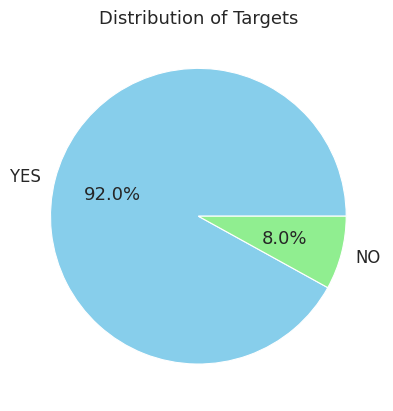

In [13]:
import matplotlib.pyplot as plt
target_df = args.dataset[args.target_var].copy()
target_df.replace({"n/a": "YES", np.nan: "YES"}, inplace=True)
counts = target_df.value_counts()
counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen'])
plt.title('Distribution of Targets')
plt.ylabel('')
target_df.replace({"YES": 0, "NO": 1}, inplace=True)
target_df.to_csv(os.path.join(DATA_PATH, f"{dataset}_targets.csv"))
plt.show()

In [14]:
from scripts.configure import configure
embedder_configs = configure(event_sequences, visit_sequences, event_sequences_type, target_df.to_dict(), X_static, args)

# Create empty dataframe for results collections
cols = ["AUC mean","AUC std","F1 mean","F1 std","Prec mean","Prec std","Recall mean","Recall std","MCC mean","MCC std","Acc mean","Acc std","CM"]
dtypes = {"AUC mean": "float64", "AUC std": "float64","F1 mean": "float64","F1 std": "float64","Prec mean": "float64","Prec std": "float64","Recall mean": "float64","Recall std": "float64","MCC mean": "float64","MCC std": "float64","Acc mean": "float64","Acc std": "float64", "CM": "string", "Brier": "float64"}

# Pre-allocate empty DataFrame with correct dtypes
results_df = pd.DataFrame(
    {c: pd.Series(dtype=dt) for c, dt in dtypes.items()},
    columns=cols
)

## Validation (Iterated 5-fold)

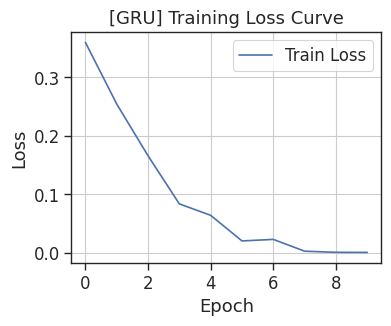

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[5]	valid_0's MCC: 0.121721
Train data (698, 4) - Test data (174, 4)

📊 Risultati medi su 5 fold:
📈 AUC:      0.6548 ± 0.0360
🧪 F1-score: 0.2619 ± 0.0859
⚖️ Precision:0.2705 ± 0.1223
🔁 Recall:   0.4143 ± 0.3010
🧮 MCC:      0.2071 ± 0.0910
🎯 Accuracy: 0.7542 ± 0.2771
🎲 Brier:     0.1003

🧩 Confusion Matrix finale (aggregata):
[[629 173]
 [ 41  29]]

📉 Calibration curve:
prob_pred = [0.04749904 0.15764063 0.25091941 0.31763406 0.42687843 0.53117897
 0.7695142 ]
prob_true = [0.06317411 0.         0.         0.16666667 0.02985075 0.19834711
 0.5       ]
STATIC+GRU AUC
STATIC+GRU F1
STATIC+GRU Prec
STATIC+GRU Recall
STATIC+GRU MCC
STATIC+GRU Acc
STATIC+GRU Brier
STATIC+GRU CM


,AUC mean,AUC std,F1 mean,F1 std,Prec mean,Prec std,Recall mean,Recall std,MCC mean,MCC std,Acc mean,Acc std,CM,Brier
STATIC,0.532552,0.083994,0.126343,0.067453,0.070822,0.038230,0.600000,0.308386,0.022304,0.075658,0.457846,0.253291,"[[357, 445], [28, 42]]",0.144729
STATIC+EVENT-CNT,0.780281,0.027636,0.294520,0.048920,0.199225,0.037720,0.571429,0.078246,0.237658,0.063321,0.777550,0.029801,"[[638, 164], [30, 40]]",0.088149
STATIC+BiPadLSTM,0.780262,0.092449,0.519271,0.032485,0.475699,0.032635,0.585714,0.104978,0.479470,0.040954,0.913997,0.006204,"[[756, 46], [29, 41]]",0.059874
STATIC+Med2Vec,0.759257,0.110755,0.339654,0.199162,0.440606,0.154820,0.300000,0.208982,0.316026,0.189725,0.919718,0.011539,"[[781, 21], [49, 21]]",0.066666
STATIC+Dipole,0.743498,0.079458,0.471522,0.089922,0.553922,0.117973,0.428571,0.101015,0.441601,0.091871,0.923159,0.017677,"[[775, 27], [40, 30]]",0.062517
STATIC+CEHR-BERT,0.800960,0.086781,0.411863,0.142549,0.401634,0.176236,0.428571,0.110657,0.358171,0.158454,0.897984,0.028735,"[[753, 49], [40, 30]]",0.069717
STATIC+DOME,0.937081,0.046178,0.594694,0.070298,0.490735,0.084625,0.771429,0.083299,0.570675,0.073975,0.914036,0.021276,"[[743, 59], [16, 54]]",0.047038
STATIC+GRU,0.662768,0.093489,0.247387,0.102566,0.634387,0.313571,0.214286,0.127775,0.271924,0.052631,0.905931,0.030837,"[[775, 27], [55, 15]]",0.069914
STATIC,0.528793,0.041644,0.125011,0.062546,0.068022,0.034030,0.771429,0.387035,0.047265,0.029882,0.315724,0.302467,"[[221, 581], [16, 54]]",0.171047
STATIC+EVENT-CNT,0.769051,0.039765,0.318867,0.071488,0.225421,0.072987,0.585714,0.083299,0.265597,0.081579,0.789097,0.053559,"[[647, 155], [29, 41]]",0.094533


In [15]:
import pickle
from scripts.cv_folding import lgbm_cv_iter
metrics = ["AUC","F1","Prec","Recall","MCC","Acc","Brier","CM"]
args.methods = [['STATIC'],
                ['STATIC', 'EVENT-CNT'], 
                ['STATIC', 'BiPadLSTM'], 
                ['STATIC', 'Med2Vec'],
                ['STATIC', 'Dipole'],
                ['STATIC', 'CEHR-BERT'],
                ['STATIC', 'DOME'],
                ['STATIC', 'GRU'],
                ]
prob_pred = {"+".join(m): [] for m in args.methods}
prob_true = {"+".join(m): [] for m in args.methods}
all_runs = {"+".join(m): ([], []) for m in args.methods}
res = {metric: {"+".join(m): [] for m in args.methods} for metric in metrics}
for i in range(args.iter):
    for m in args.methods:
        set_seed(args.random_state+i)
        results_tmp, model, _,_,_,_, results = lgbm_cv_iter(embedder_configs, target_df, args.selected_patient_ids, 
                                                            methods=m, threshold=thresh, random_state=args.random_state+i, 
                                                            return_metrics=True)
        prob_pred["+".join(m)] += list(results['calibration_prob_pred'])
        prob_true["+".join(m)] += list(results['calibration_prob_true'])
        all_runs["+".join(m)] = (all_runs["+".join(m)][0] + list(results['y_true_oof']),
                                    all_runs["+".join(m)][1] +  list(results['y_prob_oof']))
        with open(f"{args.results_dir}/results_{dataset}_{'_'.join(m)}_ITER{args.iter}.pkl", 'wb') as f:
            pickle.dump(results, f)
        for metric in res.keys():
            print("+".join(m), metric)
            res[metric]["+".join(m)] += [results[metric].tolist()] if metric == "CM" else [results[metric]] if metric == "Brier" else results[metric]
        results_df = pd.concat([results_df, results_tmp],axis=0)
for metric in res.keys():
    pd.DataFrame(res[metric]).to_csv(f"{args.results_dir}/resdata_{metric}_{dataset}_ITER{args.iter}.csv")
results_df.to_csv(f"{args.results_dir}/results_{dataset}_ITER{args.iter}.csv")
results_df


## Radar plot and performance table

& AUC & F1 & Prec & Recall & MCC & Acc & Brier & CM 0.540$\pm$0.066 & 0.132$\pm$0.062 & 0.074$\pm$0.035 & 0.646$\pm$0.330 & 0.036$\pm$0.062 & 0.428$\pm$0.255 & 0.775$\pm$0.053 & 0.316$\pm$0.074 & 0.219$\pm$0.067 & 0.600$\pm$0.125 & 0.266$\pm$0.090 & 0.786$\pm$0.047 & 0.749$\pm$0.094 & 0.402$\pm$0.099 & 0.396$\pm$0.096 & 0.426$\pm$0.136 & 0.353$\pm$0.107 & 0.900$\pm$0.022 & 0.699$\pm$0.102 & 0.307$\pm$0.133 & 0.403$\pm$0.130 & 0.260$\pm$0.137 & 0.274$\pm$0.132 & 0.911$\pm$0.015 & 0.684$\pm$0.108 & 0.388$\pm$0.125 & 0.513$\pm$0.207 & 0.340$\pm$0.132 & 0.363$\pm$0.131 & 0.916$\pm$0.020 & 0.766$\pm$0.103 & 0.372$\pm$0.146 & 0.390$\pm$0.179 & 0.369$\pm$0.142 & 0.322$\pm$0.161 & 0.900$\pm$0.026 & 0.934$\pm$0.037 & 0.603$\pm$0.108 & 0.526$\pm$0.116 & 0.729$\pm$0.144 & 0.576$\pm$0.120 & 0.922$\pm$0.026 & 0.641$\pm$0.074 & 0.270$\pm$0.119 & 0.469$\pm$0.284 & 0.286$\pm$0.230 & 0.259$\pm$0.118 & 0.862$\pm$0.169 & 

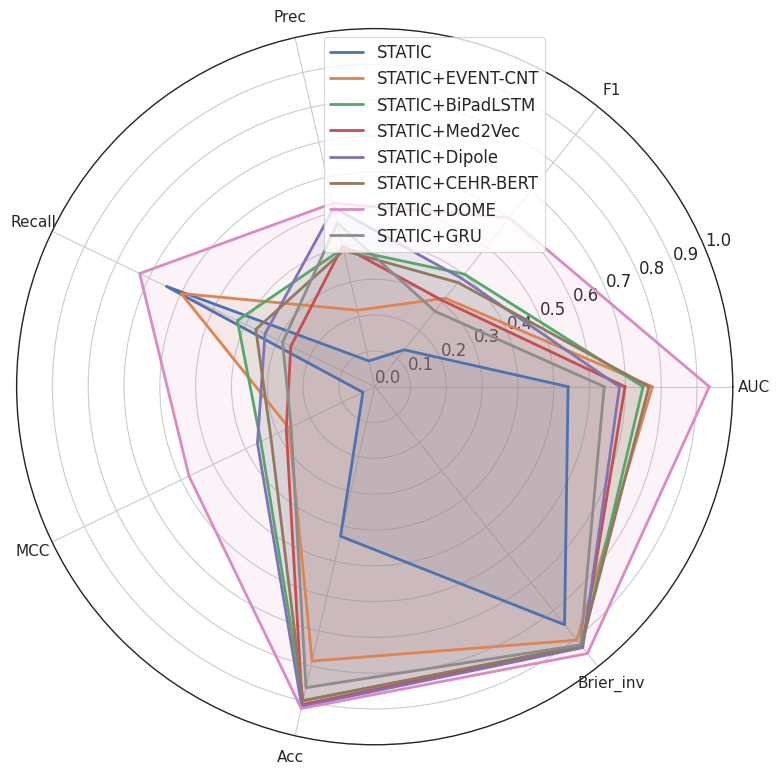

,AUC,F1,Prec,Recall,MCC,Acc,Brier,CM
Model,,,,,,,,
STATIC,0.540+0.066,0.132+0.062,0.074+0.035,0.646+0.330,0.036+0.062,0.428+0.255,0.150,"[[328.2, 473.8], [24.8, 45.2]]"
STATIC+EVENT-CNT,0.775+0.053,0.316+0.074,0.219+0.067,0.600+0.125,0.266+0.090,0.786+0.047,0.095,"[[643.4, 158.6], [28.0, 42.0]]"
STATIC+BiPadLSTM,0.749+0.094,0.402+0.099,0.396+0.096,0.426+0.136,0.353+0.107,0.900+0.022,0.073,"[[754.6, 47.4], [40.2, 29.8]]"
STATIC+Med2Vec,0.699+0.102,0.307+0.133,0.403+0.130,0.260+0.137,0.274+0.132,0.911+0.015,0.071,"[[775.8, 26.2], [51.8, 18.2]]"
STATIC+Dipole,0.684+0.108,0.388+0.125,0.513+0.207,0.340+0.132,0.363+0.131,0.916+0.020,0.068,"[[774.8, 27.2], [46.2, 23.8]]"
STATIC+CEHR-BERT,0.766+0.103,0.372+0.146,0.390+0.179,0.369+0.142,0.322+0.161,0.900+0.026,0.075,"[[758.6, 43.4], [44.2, 25.8]]"
STATIC+DOME,0.934+0.037,0.603+0.108,0.526+0.116,0.729+0.144,0.576+0.120,0.922+0.026,0.047,"[[753.0, 49.0], [19.0, 51.0]]"
STATIC+GRU,0.641+0.074,0.270+0.119,0.469+0.284,0.286+0.230,0.259+0.118,0.862+0.169,0.078,"[[732.0, 70.0], [50.0, 20.0]]"


In [16]:
import pandas as pd
import numpy as np
from scripts.plotting import plot_radar

metrics = ["AUC", "F1", "Prec", "Recall", "MCC", "Acc",]
tmetrics = metrics + ['Brier', 'CM']
dfs = {}

for metric in tmetrics:
    print(f"& {metric} ", end='')
    dfs[metric] = pd.read_csv(f"{args.results_dir}/resdata_{metric}_{dataset}_ITER{args.iter}.csv", index_col=0)
dfm = pd.DataFrame(columns = tmetrics, index = dfs[metric].columns)
dfmp = pd.DataFrame(columns = tmetrics, index = dfs[metric].columns)
dfm.index.name = "Model"
dfmp.index.name = "Model"
for method in dfs[metric].columns:
    values = []
    valuesp = []
    for metric in tmetrics:
        if metric == "CM":
            cm = dfs[metric][method].apply(lambda x: np.array(eval(x))).sum() / 5
            values += [cm]
            valuesp += [cm]
        elif metric == 'Brier':
            values += [1 - dfs[metric][method].mean()]
            valuesp += [f"{dfs[metric][method].mean():.3f}"]
        else:
            print(f"{dfs[metric][method].mean():.3f}$\pm${dfs[metric][method].std():.3f} & ", end="")
            values += [dfs[metric][method].mean()]
            valuesp += [f"{dfs[metric][method].mean():.3f}+{dfs[metric][method].std():.3f}"]
    dfm.loc[method] = values
    dfmp.loc[method] = valuesp
dfm.rename(columns={"Brier": "Brier_inv"}, inplace=True)
fig = plot_radar(dfm, metrics + ['Brier_inv'])
dfmp

## Plot calibaration curves

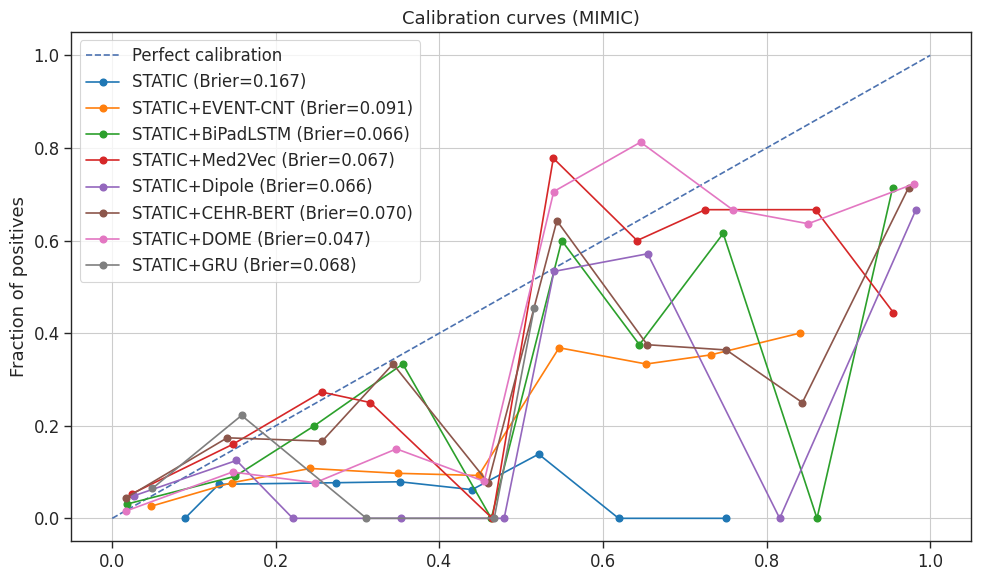

In [17]:
from scripts.plotting import plot_calibration
from scripts.utils import split_array
p_pred = {k:split_array(v)[0] for k,v in prob_pred.items()}
p_true = {k:list(v[0:len(p_pred[k])]) for k,v in prob_true.items()}
a_runs = {k:(v[0][0:1486], v[1][0:1486]) for k,v in all_runs.items()}
fig = plot_calibration(p_pred, p_true, a_runs,title=f"Calibration curves ({dataset})")